### Install and Imports

In [2]:
# !pip install torch_geometric
# !pip install xgboost

import torch
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
   classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score,
    precision_score
)

**GRAPH CREATION FULL**

In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# 1. Load and Sort Data
df = pd.read_csv('HI-Small_Trans.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(['Account', 'Timestamp']).reset_index(drop=True)

# 2. Extract NetworkX Graph Features (Node Level)
print("Computing NetworkX Centrality metrics...")
G = nx.from_pandas_edgelist(
    df, source='Account', target='Account.1', create_using=nx.DiGraph()
)

pagerank_scores = nx.pagerank(G, alpha=0.85)
hubs, authorities = nx.hits(G, max_iter=100, normalized=True)
in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)

# Topology Mappings
fan_in_map = df.groupby('Account.1')['Account'].nunique()
unique_recv_map = df.groupby('Account')['Account.1'].nunique()
user_avg_amt = df.groupby('Account')['Amount Received'].mean()

# 3. Create Node Features DataFrame
print("Building Node Features...")
unique_accounts = pd.concat([df['Account'], df['Account.1']]).unique()
accounts = pd.DataFrame({'Account': unique_accounts})

accounts['PageRank'] = accounts['Account'].map(pagerank_scores).fillna(0)
accounts['Hub_Score'] = accounts['Account'].map(hubs).fillna(0)
accounts['Authority_Score'] = accounts['Account'].map(authorities).fillna(0)
accounts['In_Degree'] = accounts['Account'].map(in_degree).fillna(0)
accounts['Out_Degree'] = accounts['Account'].map(out_degree).fillna(0)
accounts['Unique_Receivers'] = accounts['Account'].map(unique_recv_map).fillna(0)
accounts['Fan_In'] = accounts['Account'].map(fan_in_map).fillna(0)
accounts['Avg_Amount_Recv'] = accounts['Account'].map(user_avg_amt).fillna(0)

# Scale Node Features for GNN Stability
node_cols_to_scale = ['PageRank', 'Hub_Score', 'Authority_Score', 'In_Degree', 
                      'Out_Degree', 'Unique_Receivers', 'Fan_In', 'Avg_Amount_Recv']
accounts[node_cols_to_scale] = MinMaxScaler().fit_transform(accounts[node_cols_to_scale])

account_mapping = dict(zip(accounts['Account'], accounts.index))
node_features = torch.tensor(accounts[node_cols_to_scale].values, dtype=torch.float)

# 4. Create Edge/Velocity Features (Transaction Level)
print("Building Edge Velocity & Deviation Features...")
# Time since last transaction
df['Time_Since_Last_Txn'] = df.groupby('Account')['Timestamp'].diff().dt.total_seconds().fillna(0)
df['Port_Number'] = df.groupby(['Account', 'Account.1']).cumcount()

# Rolling counts and sums (Requires setting index to Timestamp temporarily)
temp_df = df.set_index('Timestamp')
r = temp_df.groupby('Account')['Amount Received']

# We map the rolling values back by aligning indexes
df['Count_1h'] = r.rolling('1h').count().values
df['Sum_1h']   = r.rolling('1h').sum().values
df['Count_24h'] = r.rolling('24h').count().values
df['Sum_24h']   = r.rolling('24h').sum().values

# Deviation Features
df['User_Avg_Amount'] = df.groupby('Account')['Amount Received'].transform('mean')
df['Amount_vs_Avg_Ratio'] = df['Amount Received'] / (df['User_Avg_Amount'] + 1)

# Normalize Time, Amounts, and Velocity metrics
edge_cols_to_scale = ['Amount Received', 'Amount Paid', 'Time_Since_Last_Txn', 
                      'Count_1h', 'Sum_1h', 'Count_24h', 'Sum_24h', 'Amount_vs_Avg_Ratio', 'Port_Number']
df[edge_cols_to_scale] = MinMaxScaler().fit_transform(df[edge_cols_to_scale])

print("Encoding Categorical Features...")
cat_cols = ['Receiving Currency', 'Payment Currency', 'Payment Format', 'From Bank', 'To Bank']
df_encoded = df.copy()

le = LabelEncoder()
for col in cat_cols:
    # Convert to string to handle any mixed types/NaNs, then label encode
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Scale the encoded integers to [0, 1] so they don't destabilize the GNN gradients
df_encoded[cat_cols] = MinMaxScaler().fit_transform(df_encoded[cat_cols])

# 5. Build PyG Data Object
print("Constructing PyTorch Geometric Data Object...")
src = df['Account'].map(account_mapping).values
dst = df['Account.1'].map(account_mapping).values

edge_indices = torch.stack([
    torch.tensor(src, dtype=torch.long), 
    torch.tensor(dst, dtype=torch.long)
], dim=0)

# Drop non-feature columns to isolate edge attributes
drop_cols = ['Timestamp', 'Account', 'Account.1', 'Is Laundering', 'User_Avg_Amount']
edge_features = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns])

edge_attr = torch.tensor(edge_features.values, dtype=torch.float)
edge_labels = torch.tensor(df['Is Laundering'].values, dtype=torch.float)

# Final Graph Construction
graph = Data(
    x=node_features,
    edge_index=edge_indices,
    edge_attr=edge_attr,
    y=edge_labels
)

print(f"Graph Construction Complete:")
print(f" - Node Feature Dimension: {graph.x.shape[1]}")
print(f" - Edge Feature Dimension: {graph.edge_attr.shape[1]}")
print(graph)

Computing NetworkX Centrality metrics...
Building Node Features...
Building Edge Velocity & Deviation Features...
Encoding Categorical Features...
Constructing PyTorch Geometric Data Object...
Graph Construction Complete:
 - Node Feature Dimension: 8
 - Edge Feature Dimension: 14
Data(x=[515080, 8], edge_index=[2, 5078345], edge_attr=[5078345, 14], y=[5078345])


**FraudGT Architecture**

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import softmax
import math

class FraudGTConv(MessagePassing):
    def __init__(self, in_channels, out_channels, edge_dim, heads=4, dropout=0.2):
        # aggr='add' because we handle the weighted averaging manually inside message()
        super(FraudGTConv, self).__init__(aggr='add', node_dim=0)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.head_dim = out_channels // heads
        
        assert self.head_dim * heads == out_channels, "out_channels must be divisible by heads"
        
        # Node Projections
        self.lin_q = nn.Linear(in_channels, out_channels)
        self.lin_k = nn.Linear(in_channels, out_channels)
        self.lin_v = nn.Linear(in_channels, out_channels)
        
        # ---> THE PAPER's SECRET WEAPONS <---
        # 1. Edge Bias: Adds transaction features directly into the Attention Score
        self.lin_edge_bias = nn.Linear(edge_dim, heads)  
        
        # 2. Edge Gate: The Smurf Filter. Learns to block noisy/normal transactions
        self.lin_edge_gate = nn.Linear(edge_dim, heads)  
        
        self.dropout = nn.Dropout(dropout)
        self.proj = nn.Linear(out_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        # Split features into multiple heads
        q = self.lin_q(x).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x).view(-1, self.heads, self.head_dim)
        
        # Start Message Passing
        out = self.propagate(edge_index, q=q, k=k, v=v, edge_attr=edge_attr)
        
        # Concatenate heads and project
        out = out.view(-1, self.out_channels)
        return self.proj(out)

    def message(self, q_i, k_j, v_j, edge_attr, index, ptr, size_i):
        # 1. Standard Query-Key Dot Product
        alpha = (q_i * k_j).sum(dim=-1) / math.sqrt(self.head_dim)  # Shape: [E, heads]
        
        # 2. Add the Edge Bias (Forces attention onto suspicious amounts/timestamps)
        edge_bias = self.lin_edge_bias(edge_attr)
        alpha = alpha + edge_bias
        
        # 3. Softmax to create probability distribution
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = self.dropout(alpha)
        
        # 4. The Edge Gate (Learns to output ~0.0 for noise, ~1.0 for real signals)
        # gate = torch.sigmoid(self.lin_edge_gate(edge_attr))
        
        # Multiply Attention Score * Gate * Value
        msg = alpha.unsqueeze(-1) * v_j
        return msg

class FraudGTModel(torch.nn.Module):
    def __init__(self, in_node_dim, in_edge_dim, hidden_dim, num_layers, heads, dropout):
        super(FraudGTModel, self).__init__()
        
        # Initial Encoders
        self.node_encoder = nn.Linear(in_node_dim, hidden_dim)
        self.edge_emb = nn.Linear(in_edge_dim, hidden_dim)
        
        # Custom FraudGT Layers
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(
                FraudGTConv(
                    in_channels=hidden_dim, 
                    out_channels=hidden_dim, 
                    edge_dim=in_edge_dim, 
                    heads=heads, 
                    dropout=dropout
                )
            )
            
        # Edge Classifier (with the degree bypass)
        clf_input_dim = (3 * hidden_dim) + 4
        self.classifier = nn.Sequential(
            nn.Linear(clf_input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        raw_degrees = x[:, -2:] 
        
        h = self.node_encoder(x)
        for conv in self.convs:
            # Note: We pass edge_attr into the custom conv here
            h = F.gelu(conv(h, edge_index, edge_attr))
            
        h_final = torch.cat([h, raw_degrees], dim=-1)
        return h_final, None

    def predict_edges(self, x_emb, edge_label_index, raw_target_edge_attr):
        src, dst = edge_label_index[0], edge_label_index[1]
        target_edge_emb = self.edge_emb(raw_target_edge_attr)
        
        edge_repr = torch.cat([x_emb[src], x_emb[dst], target_edge_emb], dim=-1)
        return self.classifier(edge_repr).squeeze(-1)

**LOSS FUNCTION**

In [26]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # inputs are raw logits
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        targets = targets.type(torch.float32)
        
        # pt is the probability of the true class
        pt = torch.exp(-BCE_loss) 
        
        # Calculate focal weight
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

**DEGREE CREATION**

In [27]:
from torch_geometric.utils import degree

# 1. Calculate the raw in-degree and out-degree for every node
# edge_index[0] is source (out-degree), edge_index[1] is destination (in-degree)
out_degree = degree(graph.edge_index[0], num_nodes=graph.num_nodes)
in_degree = degree(graph.edge_index[1], num_nodes=graph.num_nodes)

# 2. Apply Log+1 to compress massive hubs (e.g., 10,000 edges becomes ~9.2)
# This prevents giant accounts from blowing up your gradients
log_out_degree = torch.log(out_degree + 1.0).unsqueeze(-1)
log_in_degree = torch.log(in_degree + 1.0).unsqueeze(-1)

# 3. Concatenate these directly into your node features!
# Now the Transformer explicitly knows the size of every account
graph.x = torch.cat([graph.x, log_in_degree, log_out_degree], dim=-1)

print(f"Old Node Features Dim: {graph.x.shape[1] - 2}")
print(f"New Node Features Dim: {graph.x.shape[1]} (Added Log In/Out Degree)")

Old Node Features Dim: 12
New Node Features Dim: 14 (Added Log In/Out Degree)


**TRAIN TEST SPLIT, DATA LOADERS**

In [28]:
from torch_geometric.loader import LinkNeighborLoader
import torch

# 1. Temporal Splitting
num_edges = graph.num_edges
train_end = int(num_edges * 0.7)
val_end = int(num_edges * 0.85)

graph.train_mask = torch.zeros(num_edges, dtype=torch.bool)
graph.val_mask = torch.zeros(num_edges, dtype=torch.bool)
graph.test_mask = torch.zeros(num_edges, dtype=torch.bool)

graph.train_mask[:train_end] = True
graph.val_mask[train_end:val_end] = True
graph.test_mask[val_end:] = True

# 2. Extract train indices and balance
train_indices = torch.nonzero(graph.train_mask).squeeze()
illicit_train_mask = train_indices[graph.y[train_indices] == 1]
benign_train_mask = train_indices[graph.y[train_indices] == 0]

# Sample Normal Transactions (Ratio 50:1)
undersample_ratio = 50
sampled_benign_idx = benign_train_mask[torch.randperm(len(benign_train_mask))[:len(illicit_train_mask) * undersample_ratio]]

train_idx_balanced = torch.cat([illicit_train_mask, sampled_benign_idx])
train_idx_balanced = train_idx_balanced[torch.randperm(len(train_idx_balanced))]

# 3. Data Loaders (Restored to the stable setup)
train_loader = LinkNeighborLoader(
    data=graph, 
    num_neighbors=[25, 15], # Reverted to your previously stable 25, 15. Feel free to up this to 50, 50 if your RAM allows.
    edge_label_index=graph.edge_index[:, train_idx_balanced], 
    edge_label=graph.y[train_idx_balanced],
    batch_size=2048,
    shuffle=True,
)

val_loader = LinkNeighborLoader(
    data=graph, 
    num_neighbors=[25, 15],
    edge_label_index=graph.edge_index[:, graph.val_mask],
    edge_label=graph.y[graph.val_mask],
    batch_size=4096, 
    shuffle=False,
)

test_loader = LinkNeighborLoader(
    data=graph, 
    num_neighbors=[25, 15],
    edge_label_index=graph.edge_index[:, graph.test_mask],
    edge_label=graph.y[graph.test_mask],
    batch_size=4096, 
    shuffle=False,
)

**TRAINING, VALIDATION AND TESTING**

Starting training on cuda...
Epoch 03 | Time: 24.58s | Train Loss: 0.0069 | Val Loss: 0.0024 | Val F1: 0.0768 (Thresh: 0.4748)
Epoch 06 | Time: 25.16s | Train Loss: 0.0054 | Val Loss: 0.0026 | Val F1: 0.1105 (Thresh: 0.4697)
Epoch 09 | Time: 25.10s | Train Loss: 0.0051 | Val Loss: 0.0023 | Val F1: 0.1148 (Thresh: 0.4967)
Epoch 12 | Time: 24.44s | Train Loss: 0.0049 | Val Loss: 0.0021 | Val F1: 0.1261 (Thresh: 0.4755)
Epoch 15 | Time: 25.12s | Train Loss: 0.0047 | Val Loss: 0.0023 | Val F1: 0.1386 (Thresh: 0.5318)
Epoch 18 | Time: 24.94s | Train Loss: 0.0046 | Val Loss: 0.0020 | Val F1: 0.1670 (Thresh: 0.5458)
Epoch 21 | Time: 24.50s | Train Loss: 0.0044 | Val Loss: 0.0021 | Val F1: 0.1752 (Thresh: 0.5567)
Epoch 24 | Time: 25.01s | Train Loss: 0.0043 | Val Loss: 0.0020 | Val F1: 0.2046 (Thresh: 0.5555)
Epoch 27 | Time: 24.38s | Train Loss: 0.0045 | Val Loss: 0.0020 | Val F1: 0.1571 (Thresh: 0.5305)
Epoch 30 | Time: 24.65s | Train Loss: 0.0043 | Val Loss: 0.0021 | Val F1: 0.2196 (Thresh:

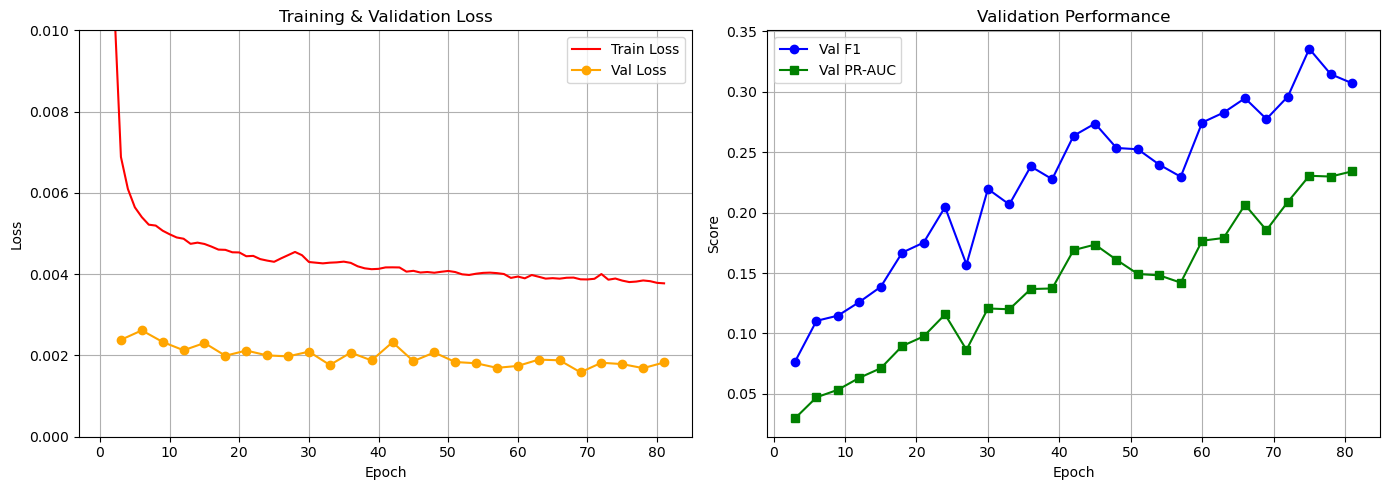


Running Final Test Evaluation...

FINAL TEST SET RESULTS
              precision    recall  f1-score   support

  Normal (0)     0.9990    0.9992    0.9991    760758
   Fraud (1)     0.2744    0.2404    0.2563       994

    accuracy                         0.9982    761752
   macro avg     0.6367    0.6198    0.6277    761752
weighted avg     0.9981    0.9982    0.9981    761752



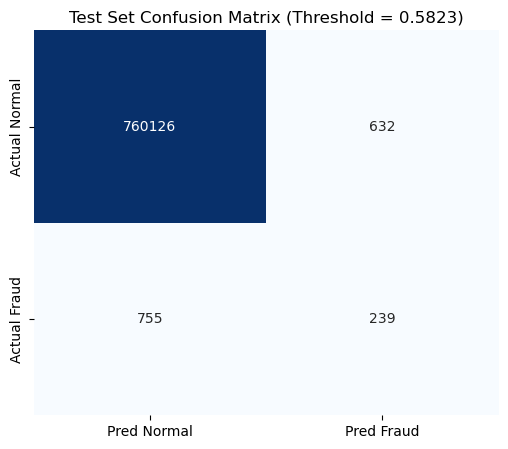

<Figure size 700x600 with 0 Axes>

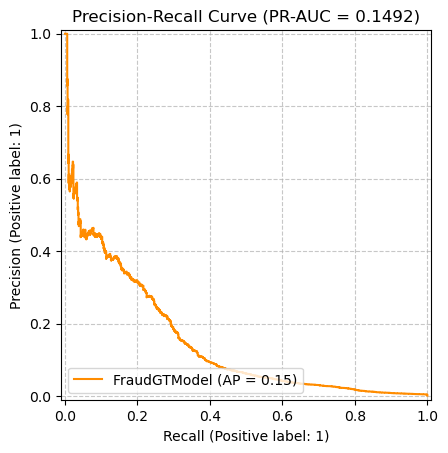

In [29]:
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch_geometric.utils import degree
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                             roc_auc_score, precision_recall_curve, 
                             average_precision_score, confusion_matrix, 
                             classification_report, PrecisionRecallDisplay)
from torch.optim.lr_scheduler import LambdaLR

# --- 1. Helper function to ensure consistent features across Train/Eval ---
def append_dynamic_features(batch, device):
    # 1. Apply Ego IDs
    ego_ids = torch.zeros(batch.num_nodes, 1, device=device)
    ego_ids[batch.edge_label_index[0]] = 1.0
    ego_ids[batch.edge_label_index[1]] = 1.0
    
    # 2. Add Degrees
    row, col = batch.edge_index
    in_deg = degree(col, batch.num_nodes).view(-1, 1).to(device)
    out_deg = degree(row, batch.num_nodes).view(-1, 1).to(device)
    
    # Concat Original + Ego(1) + InDeg(1) + OutDeg(1) = +3 Features total
    batch.x = torch.cat([batch.x, ego_ids, in_deg, out_deg], dim=-1)
    return batch

# --- 2. Model & Optimizer Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# FIX: Changed + 1 to + 3 to account for ego_ids, in_deg, and out_deg
model = FraudGTModel(
    in_node_dim=graph.x.shape[1] + 3, 
    in_edge_dim=graph.edge_attr.shape[1], 
    hidden_dim=64, 
    num_layers=2, 
    heads=8,
    dropout=0.2
).to(device)

criterion = FocalLoss(alpha=0.75, gamma=3.0).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

val_indices = torch.nonzero(graph.val_mask).squeeze()
test_indices = torch.nonzero(graph.test_mask).squeeze()

# --- 3. Training Loop ---
def train_one_epoch():
    model.train()
    total_loss = 0
    smoothing = 0 
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Consistent feature appending
        batch = append_dynamic_features(batch, device)
        
        node_emb, _ = model(batch.x, batch.edge_index, batch.edge_attr)
        
        global_edge_idx = train_idx_balanced[batch.input_id.cpu()]
        exact_edge_attr = graph.edge_attr[global_edge_idx].to(device)
        
        logits = model.predict_edges(node_emb, batch.edge_label_index, exact_edge_attr)
        
        targets = batch.edge_label.float()
        smoothed_targets = targets * (1 - smoothing) + 0.5 * smoothing
        
        loss = criterion(logits, smoothed_targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * batch.edge_label_index.size(1)
        
    return total_loss / len(train_idx_balanced)

@torch.no_grad()
def evaluate_dynamic(loader, target_indices_map, criterion):
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    total_edges = 0
    
    for batch in loader:
        batch = batch.to(device)
        
        # Consistent feature appending
        batch = append_dynamic_features(batch, device)
        
        node_emb, _ = model(batch.x, batch.edge_index, batch.edge_attr)
        
        global_edge_idx = target_indices_map[batch.input_id.cpu()]
        exact_edge_attr = graph.edge_attr[global_edge_idx].to(device)
        
        logits = model.predict_edges(node_emb, batch.edge_label_index, exact_edge_attr)
        
        # Track Validation Loss
        loss = criterion(logits, batch.edge_label.float())
        total_loss += loss.item() * batch.edge_label_index.size(1)
        total_edges += batch.edge_label_index.size(1)
        
        all_logits.append(logits.cpu())
        all_labels.append(batch.edge_label.cpu())
        
    avg_loss = total_loss / total_edges
    probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    y_true = torch.cat(all_labels).numpy()
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    
    y_pred = (probs >= best_threshold).astype(int)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prauc = average_precision_score(y_true, probs)
    
    return avg_loss, f1, prauc, best_threshold

# --- 4. Main Execution & Tracking ---
EPOCHS = 81
best_val_f1 = 0.0

# Tracking Lists
history_epochs, history_val_epochs = [], []
history_train_loss, history_val_loss = [], []
history_val_f1, history_val_pr_auc = [], []
epoch_times = []

print(f"Starting training on {device}...")
total_start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()
    
    train_loss = train_one_epoch()
    
    epoch_end_time = time.time()
    duration = epoch_end_time - epoch_start_time
    epoch_times.append(duration)
    
    history_epochs.append(epoch)
    history_train_loss.append(train_loss)
    
    if epoch % 3 == 0:
        val_loss, val_f1, val_prauc, opt_thresh = evaluate_dynamic(val_loader, val_indices, criterion)
        scheduler.step(val_f1)
        
        history_val_epochs.append(epoch)
        history_val_loss.append(val_loss)
        history_val_f1.append(val_f1)
        history_val_pr_auc.append(val_prauc)
        
        print(f"Epoch {epoch:02d} | Time: {duration:.2f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} (Thresh: {opt_thresh:.4f})")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_fraudgt.pth')

total_end_time = time.time()
avg_epoch_time = sum(epoch_times) / len(epoch_times)

print("="*50)
print(f"TRAINING COMPLETE")
print(f"Total Wall-Clock Time: {(total_end_time - total_start_time) / 60:.2f} minutes")
print(f"Average Time per Epoch: {avg_epoch_time:.2f} seconds")
print("="*50)

# --- 5. Visualizing Training Metrics ---
plt.figure(figsize=(14, 5))

# Plot 1: Losses
plt.subplot(1, 2, 1)
plt.plot(history_epochs, history_train_loss, label='Train Loss', color='red')
plt.plot(history_val_epochs, history_val_loss, label='Val Loss', marker='o', color='orange')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0.0, 0.01)
plt.legend()
plt.grid(True)

# Plot 2: Metrics
plt.subplot(1, 2, 2)
plt.plot(history_val_epochs, history_val_f1, label='Val F1', marker='o', color='blue')
plt.plot(history_val_epochs, history_val_pr_auc, label='Val PR-AUC', marker='s', color='green')
plt.title('Validation Performance')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 6. Final Test Set Evaluation & Advanced Plots ---
@torch.no_grad()
def final_test_evaluation(loader, target_indices_map):
    print("\nRunning Final Test Evaluation...")
    model.load_state_dict(torch.load('best_fraudgt.pth'))
    model.eval()
    
    all_logits, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        batch = append_dynamic_features(batch, device)
        node_emb, _ = model(batch.x, batch.edge_index, batch.edge_attr)
        global_edge_idx = target_indices_map[batch.input_id.cpu()]
        exact_edge_attr = graph.edge_attr[global_edge_idx].to(device)
        
        logits = model.predict_edges(node_emb, batch.edge_label_index, exact_edge_attr)
        all_logits.append(logits.cpu())
        all_labels.append(batch.edge_label.cpu())
        
    probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    y_true = torch.cat(all_labels).numpy()
    
    # Calculate optimal threshold based on Test Set (or you can pass the val threshold)
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    
    y_pred = (probs >= best_threshold).astype(int)
    
    pr_auc = average_precision_score(y_true, probs)
    
    print("\n" + "="*40)
    print("FINAL TEST SET RESULTS")
    print("="*40)
    print(classification_report(y_true, y_pred, target_names=["Normal (0)", "Fraud (1)"], digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Normal', 'Pred Fraud'],
                yticklabels=['Actual Normal', 'Actual Fraud'])
    plt.title(f'Test Set Confusion Matrix (Threshold = {best_threshold:.4f})')
    plt.show()

    # PR-AUC Curve Plot
    plt.figure(figsize=(7, 6))
    PrecisionRecallDisplay.from_predictions(y_true, probs, name="FraudGTModel", color="darkorange")
    plt.title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Run it
final_test_evaluation(test_loader, test_indices)

**FINAL TEST RESULTS - EARLIER RUN**

In [ ]:
model.load_state_dict(torch.load('best_fraudgt.pth'))
# Pass test_indices to avoid scrambling
test_f1, test_auc, test_thresh = evaluate_dynamic(test_loader, test_indices)
print(f"FINAL TEST SET | F1: {test_f1:.4f} | AUC: {test_auc:.4f}")

FINAL TEST SET | F1: 0.3153 | AUC: 0.9616
